In [ ]:
# Install/import required libraries
# Note: Run this notebook in Google Colab or a local Jupyter environment
# Ensure 'Capstone_Metbrains_dataset.csv' is in the same directory

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('All libraries imported successfully.')

In [63]:
#reading our dataset and viewing the dataset to get a general idea of its structure
df = pd.read_csv("Capstone_Metbrains_dataset.csv")
display(df)


,Order_Date,Country,City,Category,Sub_Category,Segment,Sales_Channel,Payment_Mode,Sales,Quantity,Discount,Profit
0,2022-06-20,UAE,Dubai,Furniture,Snacks,Consumer,Offline,UPI,2555.49,11,0.08,255.37
1,2023-12-05,UK,London,Sports,Phones,Home Office,Online,Net Banking,1795.27,9,0.28,-332.23
2,2022-07-05,USA,Los Angeles,Electronics,Shirts,Consumer,Offline,UPI,4554.73,10,0.13,140.24
3,2024-10-05,USA,New York,Furniture,Phones,Consumer,Online,Net Banking,3107.15,13,0.14,60.70
4,2023-07-21,USA,New York,Beauty,Fitness,Consumer,Offline,Card,2781.45,12,0.20,61.78
...,...,...,...,...,...,...,...,...,...,...,...,...
1595,2023-10-17,Canada,Toronto,Furniture,Snacks,Home Office,Offline,Net Banking,4219.78,5,0.24,1475.43
1596,2021-04-16,France,Lyon,Clothing,Fitness,Corporate,Online,Net Banking,2036.60,7,0.24,382.78
1597,2021-06-11,Australia,Sydney,Sports,Cosmetics,Home Office,Offline,UPI,3705.21,3,0.18,-95.61
1598,2024-05-21,India,Mumbai,Electronics,Snacks,Corporate,Offline,Cash,4526.83,12,0.25,-127.08


In [ ]:
# Fix category-subcategory mismatches using a vectorised map (faster than iterrows)

category_remapping = {
    'Snacks': 'Groceries',
    'Phones': 'Electronics',
    'Cosmetics': 'Beauty',
    'Shirts': 'Clothing',
    'Fitness': 'Sports',
    'Chairs': 'Furniture'
}

df_corrected = df.copy()

# Map Sub_Category to its correct Category; keep original where no remapping applies
df_corrected['Category'] = (
    df_corrected['Sub_Category'].map(category_remapping)
    .fillna(df_corrected['Category'])
)

df = df_corrected
print('Category-Sub_Category assignments have been corrected.')

In [65]:
#Now we will see whether the corrections we intended to do in the
#above cell worked

unique_category_subcategory_pairs_corrected = df[['Category', 'Sub_Category']].drop_duplicates().sort_values(by=['Category', 'Sub_Category'])
print("All unique Category and Sub_Category pairings after correction:")
display(unique_category_subcategory_pairs_corrected)

All unique Category and Sub_Category pairings after correction:


,Category,Sub_Category
8,Beauty,Cosmetics
2,Clothing,Shirts
1,Electronics,Phones
5,Furniture,Chairs
0,Groceries,Snacks
4,Sports,Fitness


In [66]:
#now we try to find out the general info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_Date     1600 non-null   object 
 1   Country        1600 non-null   object 
 2   City           1600 non-null   object 
 3   Category       1600 non-null   object 
 4   Sub_Category   1600 non-null   object 
 5   Segment        1600 non-null   object 
 6   Sales_Channel  1600 non-null   object 
 7   Payment_Mode   1600 non-null   object 
 8   Sales          1600 non-null   float64
 9   Quantity       1600 non-null   int64  
 10  Discount       1600 non-null   float64
 11  Profit         1600 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 150.1+ KB


In [ ]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found.')

# Check for duplicates
num_duplicates = df.duplicated().sum()
if num_duplicates == 0:
    print('No duplicates found in the dataset')
else:
    print(f'There are {num_duplicates} duplicate rows in the dataset')

# Fix Order_Date dtype
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df.info()
display(df)

In [ ]:
# Save corrected dataset locally
df.to_csv('Capstone_Metbrains_dataset_corrected.csv', index=False)
print('Corrected dataset saved as Capstone_Metbrains_dataset_corrected.csv')

# If running in Google Colab, uncomment the lines below to download the file:
# from google.colab import files
# files.download('Capstone_Metbrains_dataset_corrected.csv')

From here onwards we will use the corrected dataset named as Capstone_Metbrains_dataset_corrected.csv

In [69]:
#General description of the  corrected dataset

df_corrected.describe()

,Order_Date,Sales,Quantity,Discount,Profit
count,1600,1600.000000,1600.000000,1600.000000,1600.000000
mean,2022-12-18 01:18:18,2527.242200,7.582500,0.147138,244.332881
min,2021-01-01 00:00:00,100.260000,1.000000,0.000000,-937.750000
25%,2021-11-24 18:00:00,1293.730000,4.000000,0.070000,-88.145000
50%,2022-12-02 00:00:00,2496.750000,8.000000,0.150000,138.665000
75%,2023-12-15 18:00:00,3715.987500,11.000000,0.220000,535.817500
max,2024-12-31 00:00:00,4996.120000,14.000000,0.300000,1921.420000
std,NaN,1410.954469,3.999618,0.085156,515.339896


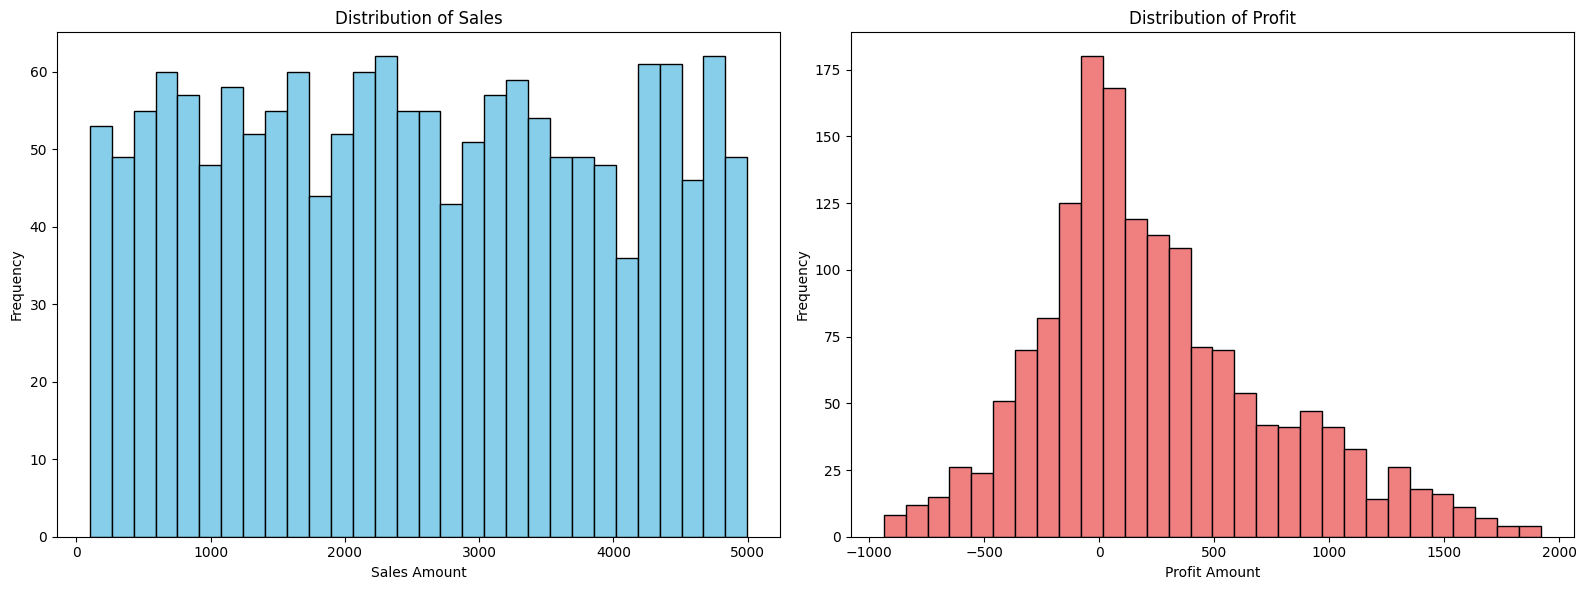

In [70]:
#To analyse the distribution of the key variables, the best starting position is to describe them visually

# Creating subplots for Sales and Profit distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of Sales
axes[0].hist(df_corrected['Sales'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Sales')
axes[0].set_xlabel('Sales Amount')
axes[0].set_ylabel('Frequency')

# Distribution of Profit
axes[1].hist(df_corrected['Profit'], bins=30, color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution of Profit')
axes[1].set_xlabel('Profit Amount')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


The histogram output cell displays two histograms: one showing the distribution of 'Sales' and the other showing the distribution of 'Profit'.

Distribution of Sales: This histogram illustrates the frequency of different sales amounts, helping to visualize the concentration and spread of sales values.
Distribution of Profit: This histogram shows the frequency of various profit amounts, indicating the range and common profit levels, including any losses (negative profit).

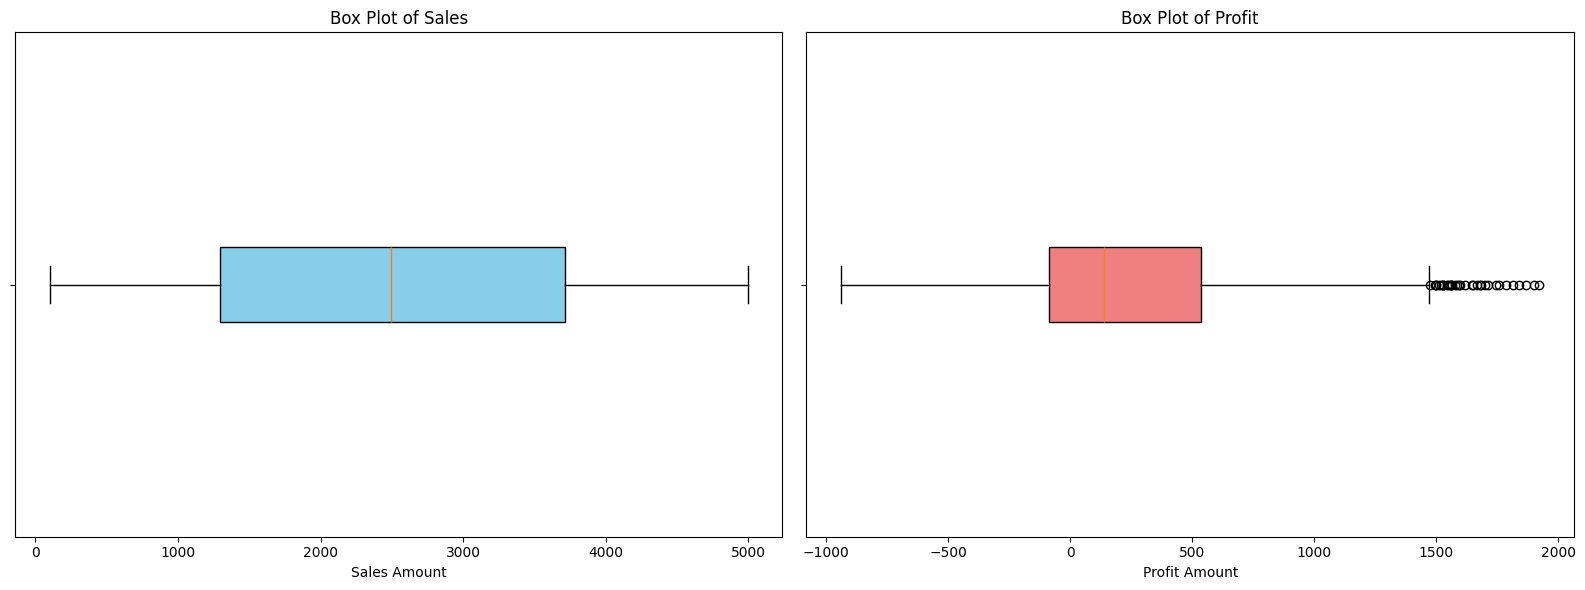

In [71]:

# Creating subplots for Sales and Profit box plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot for Sales
axes[0].boxplot(df_corrected['Sales'], vert=False, patch_artist=True, boxprops=dict(facecolor='skyblue'))
axes[0].set_title('Box Plot of Sales')
axes[0].set_xlabel('Sales Amount')
axes[0].set_yticklabels([]) # Remove y-tick labels for single box plot

# Box plot for Profit
axes[1].boxplot(df_corrected['Profit'], vert=False, patch_artist=True, boxprops=dict(facecolor='lightcoral'))
axes[1].set_title('Box Plot of Profit')
axes[1].set_xlabel('Profit Amount')
axes[1].set_yticklabels([]) # Remove y-tick labels for single box plot

plt.tight_layout()
plt.show()

The box plots for 'Sales' and 'Profit' provide a visual summary of their distributions, highlighting key statistical measures:

Central Line (Median): This line inside the box indicates the median value of sales or profit. Half of the data points are above this value, and half are below.
The Box (Interquartile Range - IQR): The box itself represents the middle 50% of the data. The bottom of the box is the first quartile (Q1), and the top is the third quartile (Q3). This means 25% of the data falls below Q1, and 25% falls above Q3.
Whiskers: These lines extend from the box to the minimum and maximum values within 1.5 times the IQR from Q1 and Q3, respectively. They show the spread of the bulk of the data.
Outliers: Any data points falling outside the whiskers are considered outliers and are plotted individually. These can represent unusually high or low sales or profit values.
In summary, these box plots help us quickly understand the typical range, central tendency, and variability of sales and profit, as well as identify any extreme values.

In [72]:
# Function to find outliers using IQR method
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Find outliers for 'Sales'
sales_outliers = find_outliers_iqr(df_corrected, 'Sales')
print("\nOutliers in Sales:")
if not sales_outliers.empty:
    display(sales_outliers)
else:
    print("No significant sales outliers found based on IQR method.")

# Find outliers for 'Profit'
profit_outliers = find_outliers_iqr(df_corrected, 'Profit')
print("\nOutliers in Profit:")
if not profit_outliers.empty:
    display(profit_outliers)
else:
    print("No significant profit outliers found based on IQR method.")


Outliers in Sales:
No significant sales outliers found based on IQR method.

Outliers in Profit:


,Order_Date,Country,City,Category,Sub_Category,Segment,Sales_Channel,Payment_Mode,Sales,Quantity,Discount,Profit
35,2024-01-09,Germany,Berlin,Clothing,Shirts,Consumer,Online,Card,4996.12,11,0.02,1558.81
96,2022-07-12,France,Paris,Sports,Fitness,Consumer,Offline,UPI,4371.23,6,0.17,1494.27
101,2021-10-11,UAE,Abu Dhabi,Furniture,Chairs,Corporate,Offline,UPI,4874.84,5,0.26,1699.84
238,2021-07-31,Germany,Munich,Furniture,Chairs,Consumer,Online,UPI,4730.45,10,0.29,1837.24
301,2024-04-25,Australia,Perth,Groceries,Snacks,Consumer,Online,Net Banking,4334.97,8,0.03,1710.17
337,2021-01-20,UAE,Abu Dhabi,Groceries,Snacks,Consumer,Online,Card,4596.13,14,0.07,1678.78
395,2023-11-16,UAE,Dubai,Clothing,Shirts,Consumer,Offline,UPI,4944.01,12,0.21,1921.42
397,2021-01-07,Australia,Sydney,Furniture,Chairs,Home Office,Offline,Card,4444.00,5,0.10,1595.90
475,2023-02-04,USA,Chicago,Clothing,Shirts,Corporate,Online,Net Banking,4137.84,9,0.10,1555.84
616,2023-02-14,Australia,Perth,Sports,Fitness,Home Office,Online,UPI,4723.45,5,0.00,1592.49


Outliers in Sales: No significant outliers were found in the 'Sales' column based on the IQR method. This suggests that the sales data does not contain values that are unusually high or low compared to the rest of the distribution.

Outliers in Profit: However, several outliers were detected in the 'Profit' column. These are transactions where the profit values fall outside the typical range, either being significantly lower (losses) or significantly higher than what is common for the dataset. The table displayed shows these specific transactions, including their 'Order_Date', 'Country', 'City', 'Category', 'Sub_Category', 'Segment', 'Sales_Channel', 'Payment_Mode', 'Sales', 'Quantity', 'Discount', and importantly, the 'Profit' value that flagged them as outliers.

These outlier profit values could represent unusual business events, highly successful sales, or significant losses, and further investigation into these specific transactions might be beneficial to understand their root causes.

In [73]:
print("Detailed information for profit outlier transactions:")
display(profit_outliers)

Detailed information for profit outlier transactions:


,Order_Date,Country,City,Category,Sub_Category,Segment,Sales_Channel,Payment_Mode,Sales,Quantity,Discount,Profit
35,2024-01-09,Germany,Berlin,Clothing,Shirts,Consumer,Online,Card,4996.12,11,0.02,1558.81
96,2022-07-12,France,Paris,Sports,Fitness,Consumer,Offline,UPI,4371.23,6,0.17,1494.27
101,2021-10-11,UAE,Abu Dhabi,Furniture,Chairs,Corporate,Offline,UPI,4874.84,5,0.26,1699.84
238,2021-07-31,Germany,Munich,Furniture,Chairs,Consumer,Online,UPI,4730.45,10,0.29,1837.24
301,2024-04-25,Australia,Perth,Groceries,Snacks,Consumer,Online,Net Banking,4334.97,8,0.03,1710.17
337,2021-01-20,UAE,Abu Dhabi,Groceries,Snacks,Consumer,Online,Card,4596.13,14,0.07,1678.78
395,2023-11-16,UAE,Dubai,Clothing,Shirts,Consumer,Offline,UPI,4944.01,12,0.21,1921.42
397,2021-01-07,Australia,Sydney,Furniture,Chairs,Home Office,Offline,Card,4444.00,5,0.10,1595.90
475,2023-02-04,USA,Chicago,Clothing,Shirts,Corporate,Online,Net Banking,4137.84,9,0.10,1555.84
616,2023-02-14,Australia,Perth,Sports,Fitness,Home Office,Online,UPI,4723.45,5,0.00,1592.49


The table above shows each individual transaction that was flagged as an outlier, including its Order_Date, Country, City, Category, Sub_Category, Segment, Sales_Channel, Payment_Mode, Sales, Quantity, Discount, and most importantly, the Profit amount that made it an outlier.

This detailed view allows us to observe specific characteristics of these outlier transactions. For example, we can see transactions with very high profits (e.g., Row 35 with a profit of 1921.42) and also transactions with significant losses (e.g., Row 1595 with a profit of -937.75). These details can be crucial for understanding the drivers of extreme profitability or losses within the business.

### Analyzing Commonalities Among Profit Outliers

Let's examine the distribution of categorical features within the `profit_outliers` DataFrame to identify any common patterns or concentrations that might explain why these transactions are outliers.

In [74]:
print("\n--- Distribution of Categories among Profit Outliers ---")
display(profit_outliers['Category'].value_counts())

print("\n--- Distribution of Sub-Categories among Profit Outliers ---")
display(profit_outliers['Sub_Category'].value_counts())

print("\n--- Distribution of Countries among Profit Outliers ---")
display(profit_outliers['Country'].value_counts())

print("\n--- Distribution of Cities among Profit Outliers ---")
display(profit_outliers['City'].value_counts())

print("\n--- Distribution of Segments among Profit Outliers ---")
display(profit_outliers['Segment'].value_counts())

print("\n--- Distribution of Sales Channels among Profit Outliers ---")
display(profit_outliers['Sales_Channel'].value_counts())

print("\n--- Distribution of Payment Modes among Profit Outliers ---")
display(profit_outliers['Payment_Mode'].value_counts())


--- Distribution of Categories among Profit Outliers ---


,count
Category,
Furniture,9
Sports,7
Clothing,6
Beauty,5
Groceries,4
Electronics,4



--- Distribution of Sub-Categories among Profit Outliers ---


,count
Sub_Category,
Chairs,9
Fitness,7
Shirts,6
Cosmetics,5
Snacks,4
Phones,4



--- Distribution of Countries among Profit Outliers ---


...

,count
Segment,
Consumer,16
Home Office,11
Corporate,8



--- Distribution of Sales Channels among Profit Outliers ---


,count
Sales_Channel,
Online,22
Offline,13



--- Distribution of Payment Modes among Profit Outliers ---


,count
Payment_Mode,
Net Banking,16
UPI,7
Card,6
Cash,6


The analysis of commonalities among profit outliers has provided some initial insights:

Category Distribution: Among the profit outliers, 'Furniture' appears most frequently (9 occurrences), followed by 'Sports' (7), and 'Clothing' (6). 'Beauty', 'Groceries', and 'Electronics' have fewer outlier instances.
Sub-Category Distribution: Correspondingly, 'Chairs' (part of Furniture) is the most frequent sub-category among outliers (9 occurrences), followed by 'Fitness' (7, part of Sports) and 'Shirts' (6, part of Clothing).

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sales', y='Profit', data=df_corrected, alpha=0.6)
plt.title('Sales vs. Profit')
plt.xlabel('Sales Amount')
plt.ylabel('Profit Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The scatter plot displays the relationship between 'Sales' and 'Profit'. Each point on the graph represents a single transaction, with its 'Sales Amount' on the x-axis and 'Profit Amount' on the y-axis. This visualization helps in identifying patterns such as:

Positive correlation: If points generally trend upwards from left to right, it suggests that higher sales tend to lead to higher profits.
Negative correlation: If points generally trend downwards, it indicates that higher sales are associated with lower profits.
No clear correlation: If points are scattered randomly, there might not be a strong linear relationship.
Outliers: Points that are far away from the main cluster can represent transactions with unusually high sales but low profit (or even loss), or vice-versa.
From the plot, you can observe how profit varies with sales and identify any specific segments where profit margins might be different.

In [76]:
df_corrected['Year'] = df_corrected['Order_Date'].dt.year

yearly_performance = df_corrected.groupby('Year')[['Sales', 'Profit']].sum().reset_index()
display(yearly_performance)

,Year,Sales,Profit
0,2021,1081893.94,115154.74
1,2022,1008685.39,79021.02
2,2023,977451.35,102923.76
3,2024,975556.84,93833.09


Now, let's visualize the yearly sales and profit performance using line plots to observe the trends over time.

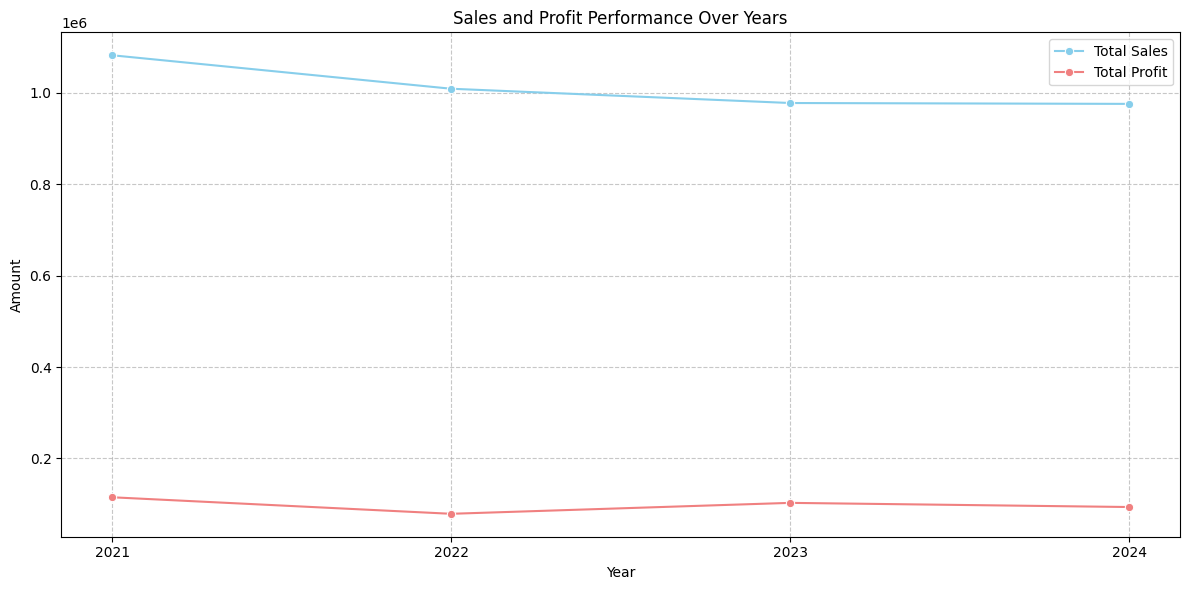

In [77]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Sales', data=yearly_performance, marker='o', label='Total Sales', color='skyblue')
sns.lineplot(x='Year', y='Profit', data=yearly_performance, marker='o', label='Total Profit', color='lightcoral')

plt.title('Sales and Profit Performance Over Years')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.xticks(yearly_performance['Year'].unique())
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

,Country,Sales,Profit
0,Australia,532962.41,44260.35
1,Canada,519270.73,45124.73
2,France,489668.51,51087.55
3,Germany,463782.57,46524.36
4,India,573086.68,56905.04
5,UAE,538894.26,46844.97
6,UK,451689.82,48235.33
7,USA,474232.54,51950.28


/tmp/ipykernel_4978/1260291247.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales', y='Country', data=country_performance.sort_values('Sales', ascending=False), ax=axes[0], palette='viridis')
/tmp/ipykernel_4978/1260291247.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Profit', y='Country', data=country_performance.sort_values('Profit', ascending=False), ax=axes[1], palette='magma')


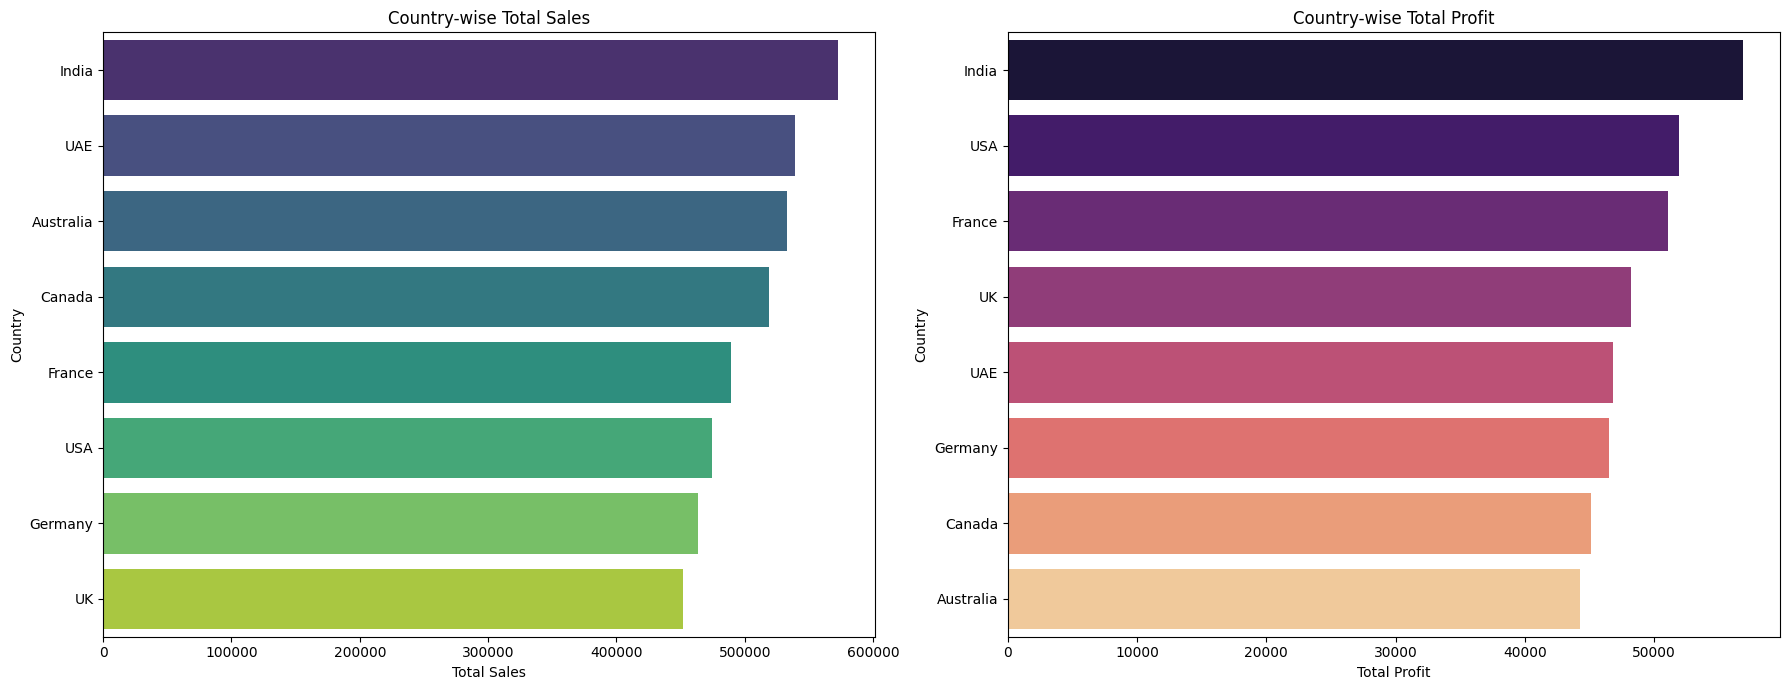

In [78]:
country_performance = df_corrected.groupby('Country')[['Sales', 'Profit']].sum().reset_index()
display(country_performance)

# Visualize country-wise sales and profit
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x='Sales', y='Country', data=country_performance.sort_values('Sales', ascending=False), ax=axes[0], palette='viridis')
axes[0].set_title('Country-wise Total Sales')
axes[0].set_xlabel('Total Sales')
axes[0].set_ylabel('Country')

sns.barplot(x='Profit', y='Country', data=country_performance.sort_values('Profit', ascending=False), ax=axes[1], palette='magma')
axes[1].set_title('Country-wise Total Profit')
axes[1].set_xlabel('Total Profit')
axes[1].set_ylabel('Country')

plt.tight_layout()
plt.show()

From this table, we can observe that India has the highest total sales and also the highest total profit, indicating a strong market presence and profitability. The UK has the lowest sales, while Australia has the lowest profit among the listed countries.

Country-wise Sales and Profit Bar Plots:
The two bar plots visually represent this data:

Country-wise Total Sales (Left Plot): This bar plot, sorted by sales in descending order, clearly shows India leading in total sales, followed by UAE, Australia, and Canada, with the UK having the lowest sales.
Country-wise Total Profit (Right Plot): Similarly, this bar plot, sorted by profit in descending order, highlights India as the most profitable country, followed closely by USA and France.
These visualizations make it easy to compare the performance of different countries at a glance. It's interesting to note that while some countries like France and USA have moderate sales, their profit margins are relatively higher compared to countries with similar or higher sales.

,Category,Sales,Profit
0,Beauty,671038.30,55265.69
1,Clothing,673587.90,68884.14
2,Electronics,703566.26,80311.92
3,Furniture,747812.68,74521.08
4,Groceries,651573.99,54579.10
5,Sports,596008.39,57370.68


/tmp/ipykernel_4978/1030760806.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales', y='Category', data=category_performance.sort_values('Sales', ascending=False), ax=axes[0], palette='viridis')
/tmp/ipykernel_4978/1030760806.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Profit', y='Category', data=category_performance.sort_values('Profit', ascending=False), ax=axes[1], palette='magma')


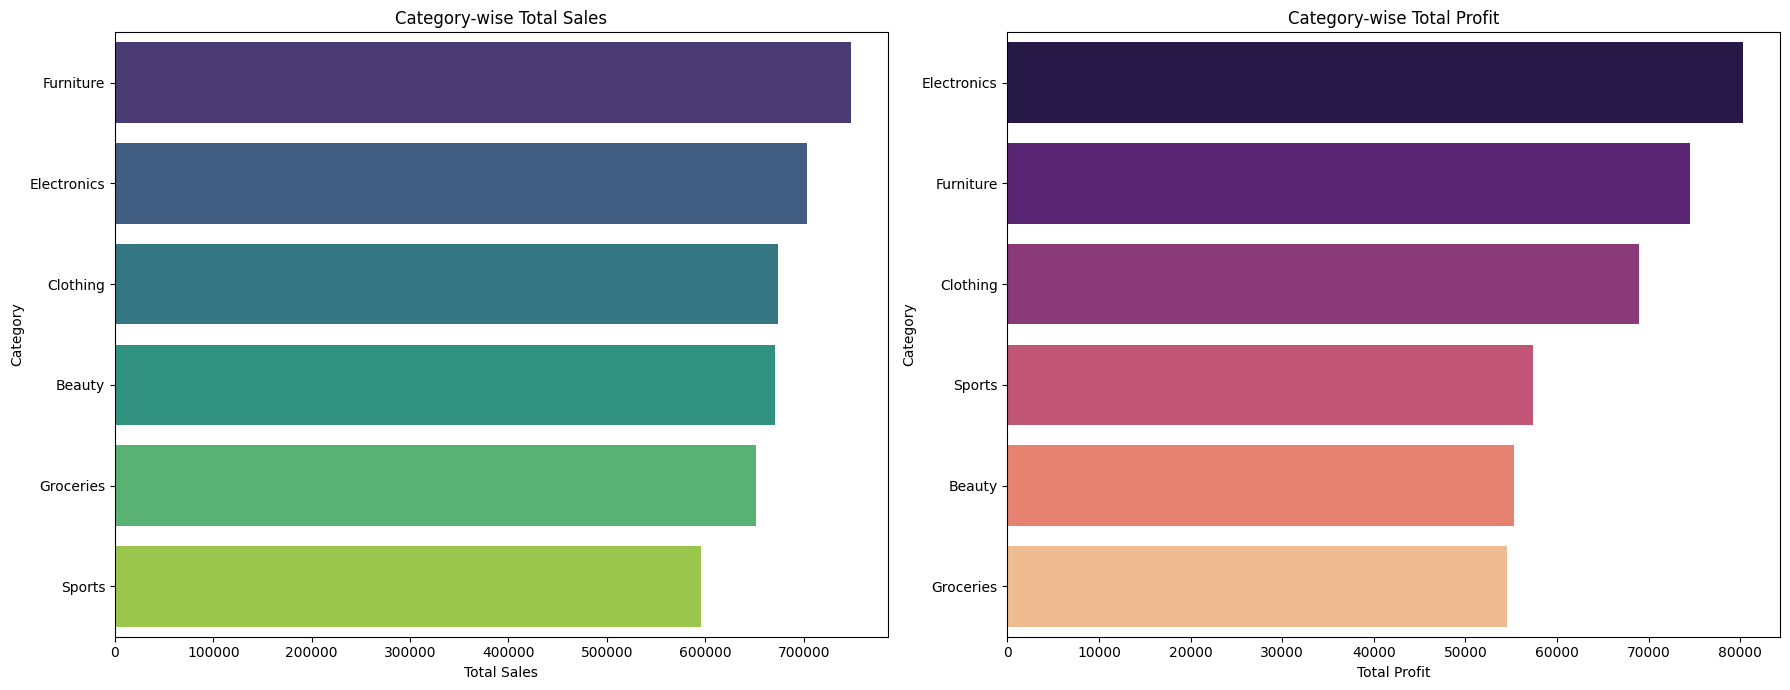

In [79]:
category_performance = df_corrected.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
display(category_performance)

# Now, let's visualize the category-wise sales and profit performance using bar plots to easily compare the different categories.
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x='Sales', y='Category', data=category_performance.sort_values('Sales', ascending=False), ax=axes[0], palette='viridis')
axes[0].set_title('Category-wise Total Sales')
axes[0].set_xlabel('Total Sales')
axes[0].set_ylabel('Category')

sns.barplot(x='Profit', y='Category', data=category_performance.sort_values('Profit', ascending=False), ax=axes[1], palette='magma')
axes[1].set_title('Category-wise Total Profit')
axes[1].set_xlabel('Total Profit')
axes[1].set_ylabel('Category')

plt.tight_layout()
plt.show()

Observations from the Table and Bar Plots:

Sales Performance: Furniture leads in total sales, followed by Electronics, Clothing, Beauty, Groceries, and Sports. This indicates that furniture and electronics are the highest revenue-generating categories.
Profit Performance: Electronics generates the highest profit, closely followed by Furniture and Clothing. Groceries and Beauty have the lowest profit among the categories.
Profitability vs. Sales: While Furniture has the highest sales, Electronics yields slightly more profit, suggesting better profit margins in the electronics category. Sports has the lowest sales.

### Correlation Matrix Analysis

Let's generate a correlation matrix to understand the relationships between the numerical variables: 'Sales', 'Quantity', 'Discount', and 'Profit'.

,Sales,Quantity,Discount,Profit
Sales,1.000000,-0.034792,-0.030785,0.297493
Quantity,-0.034792,1.000000,-0.021855,-0.025685
Discount,-0.030785,-0.021855,1.000000,-0.034718
Profit,0.297493,-0.025685,-0.034718,1.000000


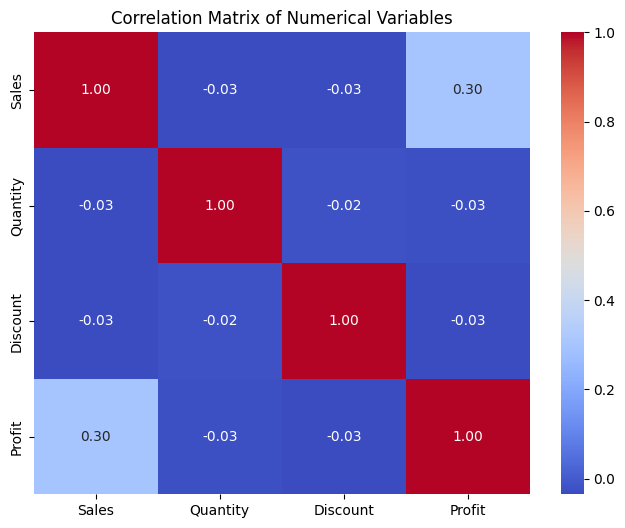

In [80]:
numerical_df = df_corrected[['Sales', 'Quantity', 'Discount', 'Profit']]
correlation_matrix = numerical_df.corr()
display(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

The correlation matrix and its heatmap are now displayed. Let's interpret these results:

Sales and Profit (0.297): There is a moderate positive correlation between Sales and Profit. This means that as sales increase, profit generally tends to increase, but not always proportionally. This makes sense as higher revenue often leads to higher profits, but other factors like discounts and costs also play a role.

Quantity and Sales (-0.035): There is a very weak negative correlation between Quantity and Sales. This suggests that the number of items sold has almost no linear relationship with the total sales amount. This could indicate a wide range in product prices, where selling fewer expensive items can result in similar sales to selling many cheaper items.

Discount and Sales (-0.031): There is a very weak negative correlation between Discount and Sales. This indicates that higher discounts do not strongly correlate with higher or lower sales volumes in a linear fashion.

Quantity and Profit (-0.026): There is a very weak negative correlation between Quantity and Profit, meaning the number of items sold doesn't have a strong linear impact on profit.

Discount and Profit (-0.035): There is a very weak negative correlation between Discount and Profit. This implies that higher discounts are very slightly associated with lower profits, which is expected, but the relationship is not strong. This could be due to discounts being strategically applied to clear inventory or boost sales of certain items without drastically impacting overall profit.

Quantity and Discount (-0.022): There is a very weak negative correlation between Quantity and Discount, suggesting almost no linear relationship between the quantity of items sold and the discount offered.

In summary, the most notable relationship is between Sales and Profit, which is positive but not extremely strong. The other numerical variables (Quantity and Discount) show very weak correlations with each other and with Sales and Profit, suggesting that their direct linear impact on sales and profit in this dataset is minimal. The heatmap visually reinforces these weak relationships, with most correlations being close to zero, except for the Sales-Profit correlation.

### Relationship between Discount and Profit

Let's visualize the relationship between 'Discount' and 'Profit' using a scatter plot.

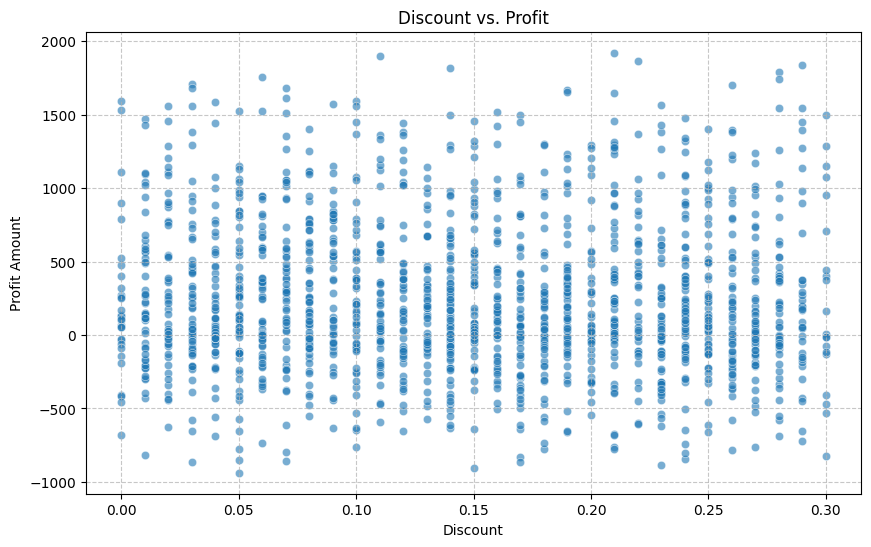

In [81]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Profit', data=df_corrected, alpha=0.6)
plt.title('Discount vs. Profit')
plt.xlabel('Discount')
plt.ylabel('Profit Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Looking at the scatter plot, we can observe that:

Wide Spread of Profits at Lower Discounts: For lower discount percentages (e.g., closer to 0), there's a wide range of profit values, including both positive profits and some losses. This suggests that other factors heavily influence profit when discounts are minimal.

Increasing Losses with Higher Discounts: As the discount percentage increases, there's a clear trend towards lower profits, and a higher concentration of negative profit (losses). Transactions with discounts above approximately 0.20 (20%) show a more pronounced tendency towards losses or significantly reduced profits.

No Strong Linear Relationship, but a Trend: While there isn't a perfectly linear relationship, the overall pattern suggests that offering higher discounts generally leads to lower profits, and often results in losses. This aligns with the weak negative correlation coefficient (around -0.035) we saw in the correlation matrix, indicating that while the relationship is not strong and consistent across all data points, the negative impact of higher discounts on profit is visible.

Outliers of High Profit with Discounts: There are still some points showing positive profits even at higher discount rates, which could represent strategic sales or products with very high base margins.

In summary, this visualization reinforces the idea that discounts, while potentially driving sales volume, can significantly erode profit margins, especially when offered at higher percentages. Businesses need to carefully consider the impact of discounts on overall profitability.

,Quarter,Sales,Profit
0,1,925771.14,88969.93
1,2,955411.13,91579.99
2,3,1071054.14,109957.18
3,4,1091351.11,100425.51


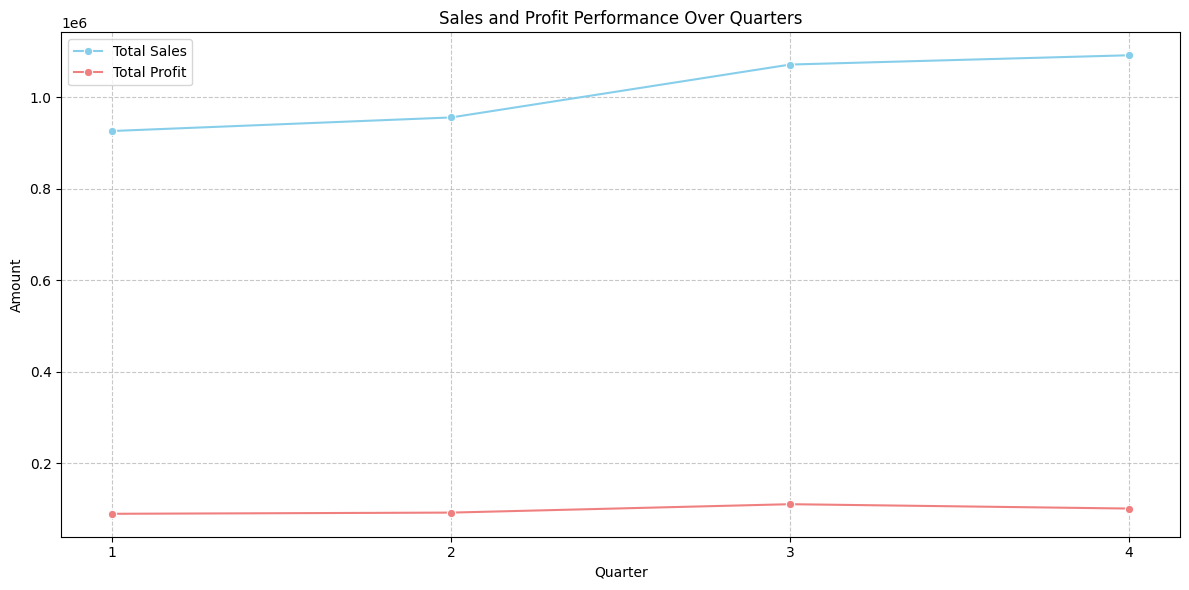

In [82]:
df_corrected['Quarter'] = df_corrected['Order_Date'].dt.quarter

quarterly_performance = df_corrected.groupby('Quarter')[['Sales', 'Profit']].sum().reset_index()
display(quarterly_performance)

plt.figure(figsize=(12, 6))
sns.lineplot(x='Quarter', y='Sales', data=quarterly_performance, marker='o', label='Total Sales', color='skyblue')
sns.lineplot(x='Quarter', y='Profit', data=quarterly_performance, marker='o', label='Total Profit', color='lightcoral')

plt.title('Sales and Profit Performance Over Quarters')
plt.xlabel('Quarter')
plt.ylabel('Amount')
plt.xticks(quarterly_performance['Quarter'].unique())
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Observations from the Table and Line Plot:

Sales Trend: Both sales and profit show an upward trend throughout the year, peaking in the third and fourth quarters. Quarter 4 consistently has the highest sales, followed closely by Quarter 3.
Profit Trend: Profit also generally increases towards the end of the year, with Quarter 3 showing the highest profit, even slightly surpassing Quarter 4 profit despite Quarter 4 having higher sales. This suggests potentially better profit margins or different product mixes in Quarter 3.
Cyclical Pattern: There is a strong cyclical pattern where the business performs weakest in Q1 and gradually grows, reaching its strongest performance in Q3 and Q4. This could indicate seasonal demand, holiday shopping, or other year-end activities boosting sales and profit.
This visualization clearly demonstrates that the business experiences a significant surge in activity and profitability in the latter half of the year.

### Quarterly Sales and Profit Trends by Product Category

,Category,Quarter,Sales,Profit
0,Beauty,1,156842.00,9501.21
1,Beauty,2,129477.39,13921.19
2,Beauty,3,186316.49,15780.60
3,Beauty,4,198402.42,16062.69
4,Clothing,1,191713.87,26234.65
5,Clothing,2,131451.95,13914.50
6,Clothing,3,156043.90,10327.26
7,Clothing,4,194378.18,18407.73
8,Electronics,1,143000.76,17816.89
9,Electronics,2,205616.70,21617.10


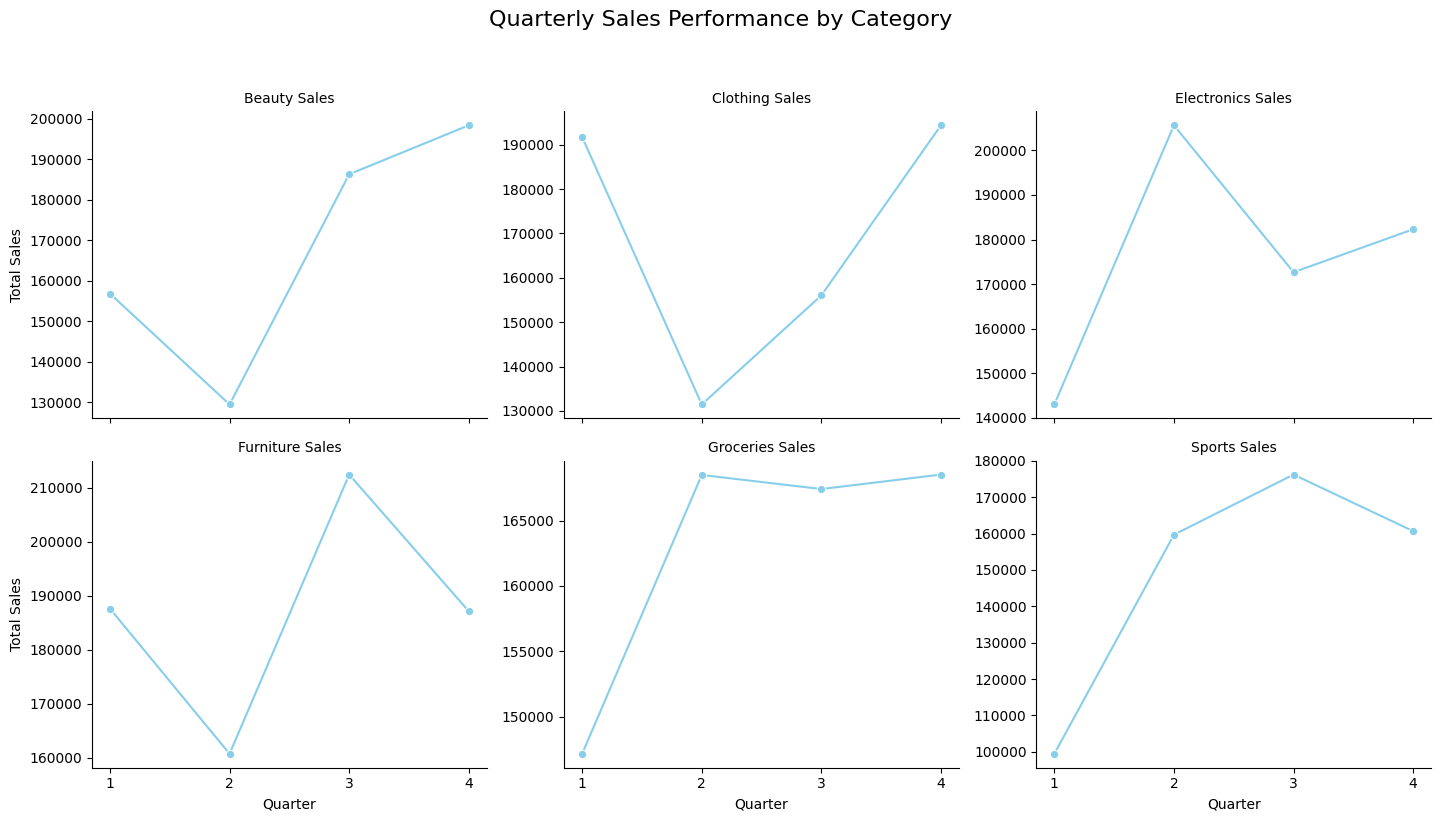

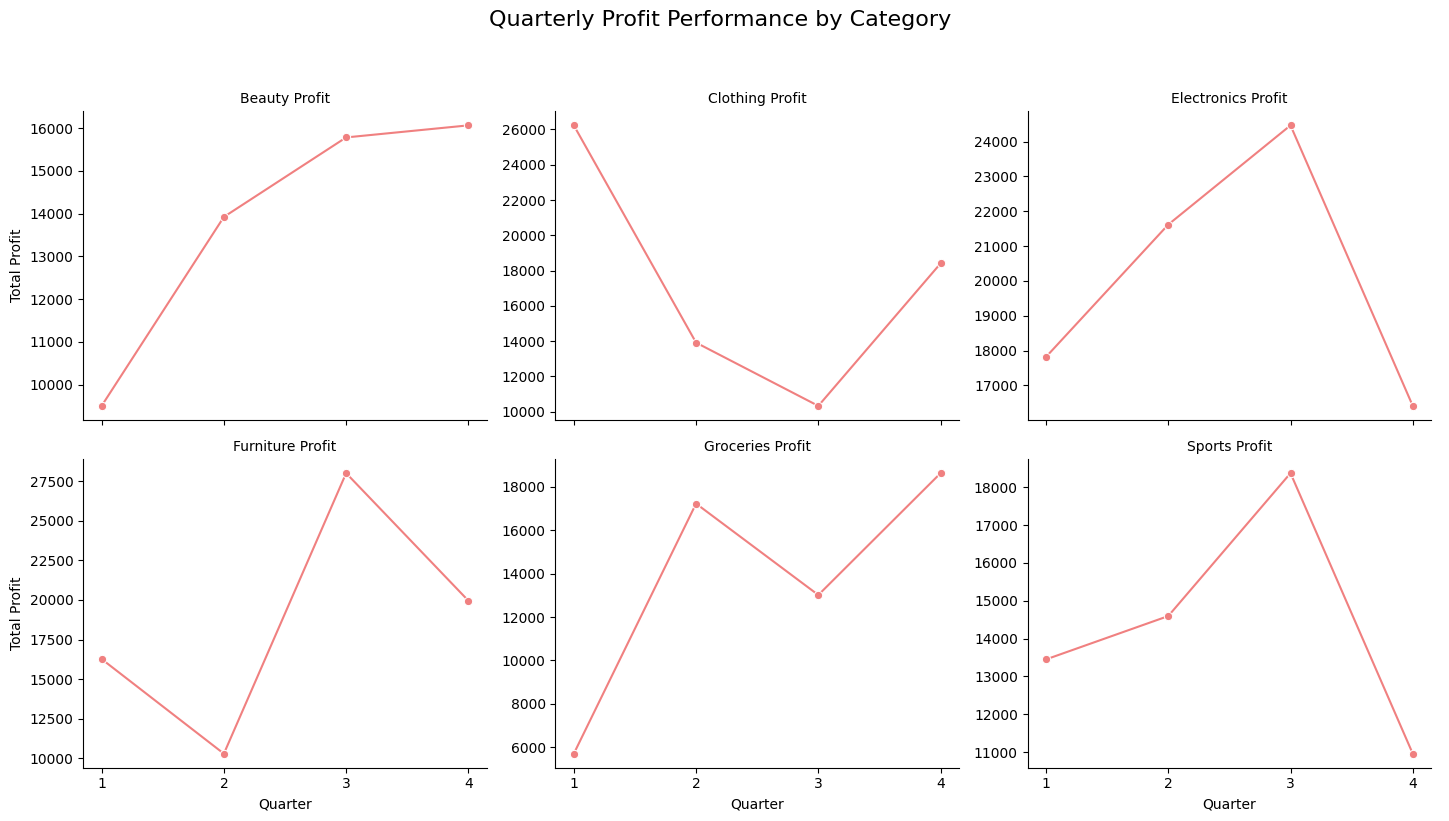

In [83]:
category_quarterly_performance = df_corrected.groupby(['Category', 'Quarter'])[['Sales', 'Profit']].sum().reset_index()
display(category_quarterly_performance)

# Visualize quarterly sales trends by category
g = sns.FacetGrid(category_quarterly_performance, col='Category', col_wrap=3, height=4, aspect=1.2, sharey=False)
g.map(sns.lineplot, 'Quarter', 'Sales', marker='o', color='skyblue')
g.set_titles('{col_name} Sales')
g.set_axis_labels('Quarter', 'Total Sales')
g.set(xticks=[1, 2, 3, 4])
g.add_legend()
plt.suptitle('Quarterly Sales Performance by Category', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# Visualize quarterly profit trends by category
g = sns.FacetGrid(category_quarterly_performance, col='Category', col_wrap=3, height=4, aspect=1.2, sharey=False)
g.map(sns.lineplot, 'Quarter', 'Profit', marker='o', color='lightcoral')
g.set_titles('{col_name} Profit')
g.set_axis_labels('Quarter', 'Total Profit')
g.set(xticks=[1, 2, 3, 4])
g.add_legend()
plt.suptitle('Quarterly Profit Performance by Category', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Observations from the Plots:

Beauty: Shows a steady increase in both sales and profit from Q2 to Q4, with Q1 being the lowest. This suggests a strong year-end peak.
Clothing: Experiences a dip in sales and profit in Q2 and Q3, recovering significantly in Q4 and starting strong in Q1. This might indicate seasonal fashion cycles or holiday demand.
Electronics: Displays its highest sales and profit in Q2, with Q3 also strong for profit. Sales and profit in Q1 and Q4 are lower by comparison, potentially indicating mid-year product releases or promotional cycles.
Furniture: Shows a pronounced peak in sales and profit in Q3, with Q1 and Q4 also strong for sales. Q2 is the weakest quarter. This could be related to home renovation seasons or end-of-year sales.
Groceries: Exhibits relatively stable sales across quarters, with a slight increase in Q2. Profit, however, is significantly lower in Q1 compared to other quarters, which show more consistent profit levels.
Sports: Sales and profit both gradually increase from Q1 to Q3, with Q3 being the strongest. Q4 sees a slight decline in both, indicating a potential build-up to summer or outdoor activity seasons.
Overall, these category-specific trends provide valuable insights into seasonal demand and operational performance, allowing for more targeted marketing and inventory management strategies.

### Sales and Profit Performance by Sales Channel

,Sales_Channel,Sales,Profit
0,Offline,2089339.70,202115.03
1,Online,1954247.82,188817.58


/tmp/ipykernel_4978/2754101069.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales_Channel', y='Sales', data=sales_channel_performance.sort_values('Sales', ascending=False), ax=axes[0], palette='viridis')
/tmp/ipykernel_4978/2754101069.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales_Channel', y='Profit', data=sales_channel_performance.sort_values('Profit', ascending=False), ax=axes[1], palette='magma')


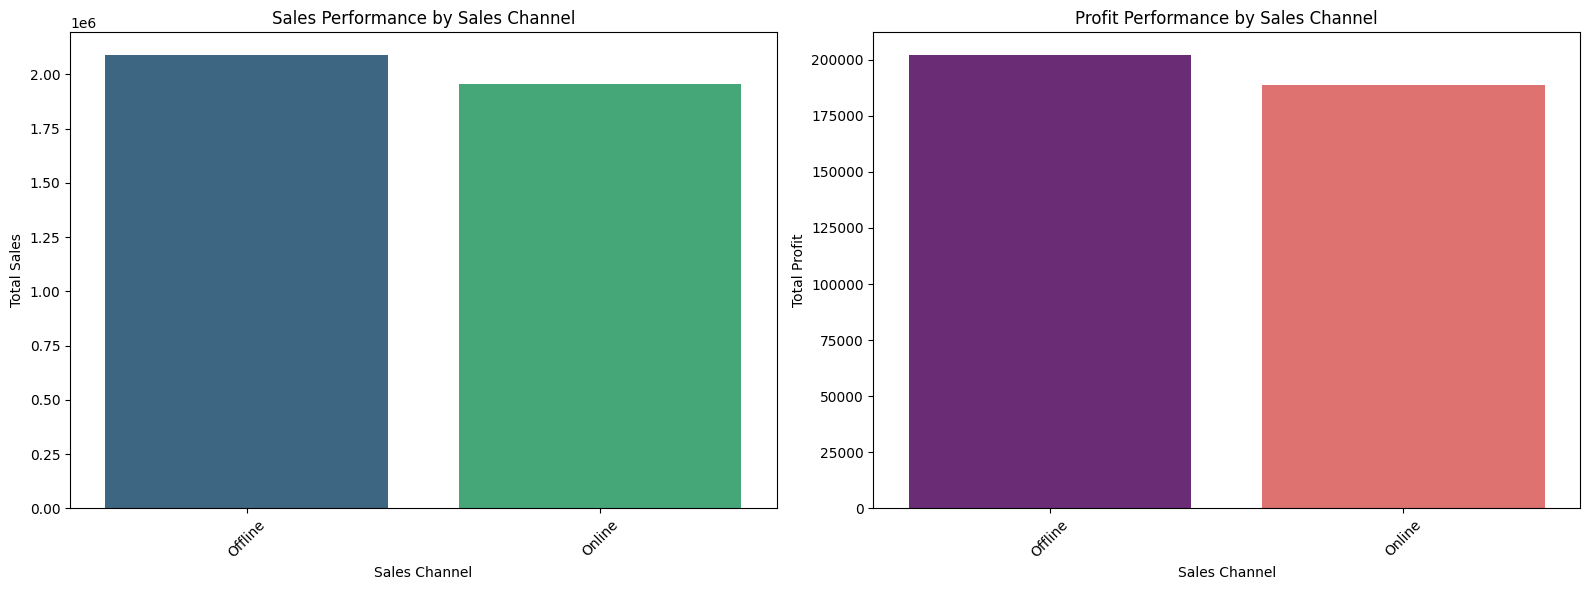

In [84]:
sales_channel_performance = df_corrected.groupby('Sales_Channel')[['Sales', 'Profit']].sum().reset_index()
display(sales_channel_performance)

# Visualize sales and profit by sales channel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Sales_Channel', y='Sales', data=sales_channel_performance.sort_values('Sales', ascending=False), ax=axes[0], palette='viridis')
axes[0].set_title('Sales Performance by Sales Channel')
axes[0].set_xlabel('Sales Channel')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x='Sales_Channel', y='Profit', data=sales_channel_performance.sort_values('Profit', ascending=False), ax=axes[1], palette='magma')
axes[1].set_title('Profit Performance by Sales Channel')
axes[1].set_xlabel('Sales Channel')
axes[1].set_ylabel('Total Profit')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Observations from the Table and Bar Plots:

Offline Channel Leads: The 'Offline' sales channel generates slightly higher total sales and profit compared to the 'Online' channel.
Offline Sales: Approximately 2.09 million
Online Sales: Approximately 1.95 million
Offline Profit: Approximately 202,115
Online Profit: Approximately 188,817
This indicates that while both channels are significant contributors, the traditional 'Offline' approach currently has a marginally stronger performance in both revenue and profitability.

In [85]:
df_corrected['Profit_Margin'] = (df_corrected['Profit'] / df_corrected['Sales']) * 100

# Overall Average Profit Margin
overall_avg_profit_margin = df_corrected['Profit_Margin'].mean()
print(f"Overall Average Profit Margin: {overall_avg_profit_margin:.2f}%")

Overall Average Profit Margin: 9.37%


### Profit Margin Analysis: Segment, Category, and Region

These visualizations provide insights into how profit margins vary across different segments, product categories, and geographical regions. Understanding these differences can help in identifying areas of high profitability and areas that may require strategic adjustments to improve margins.

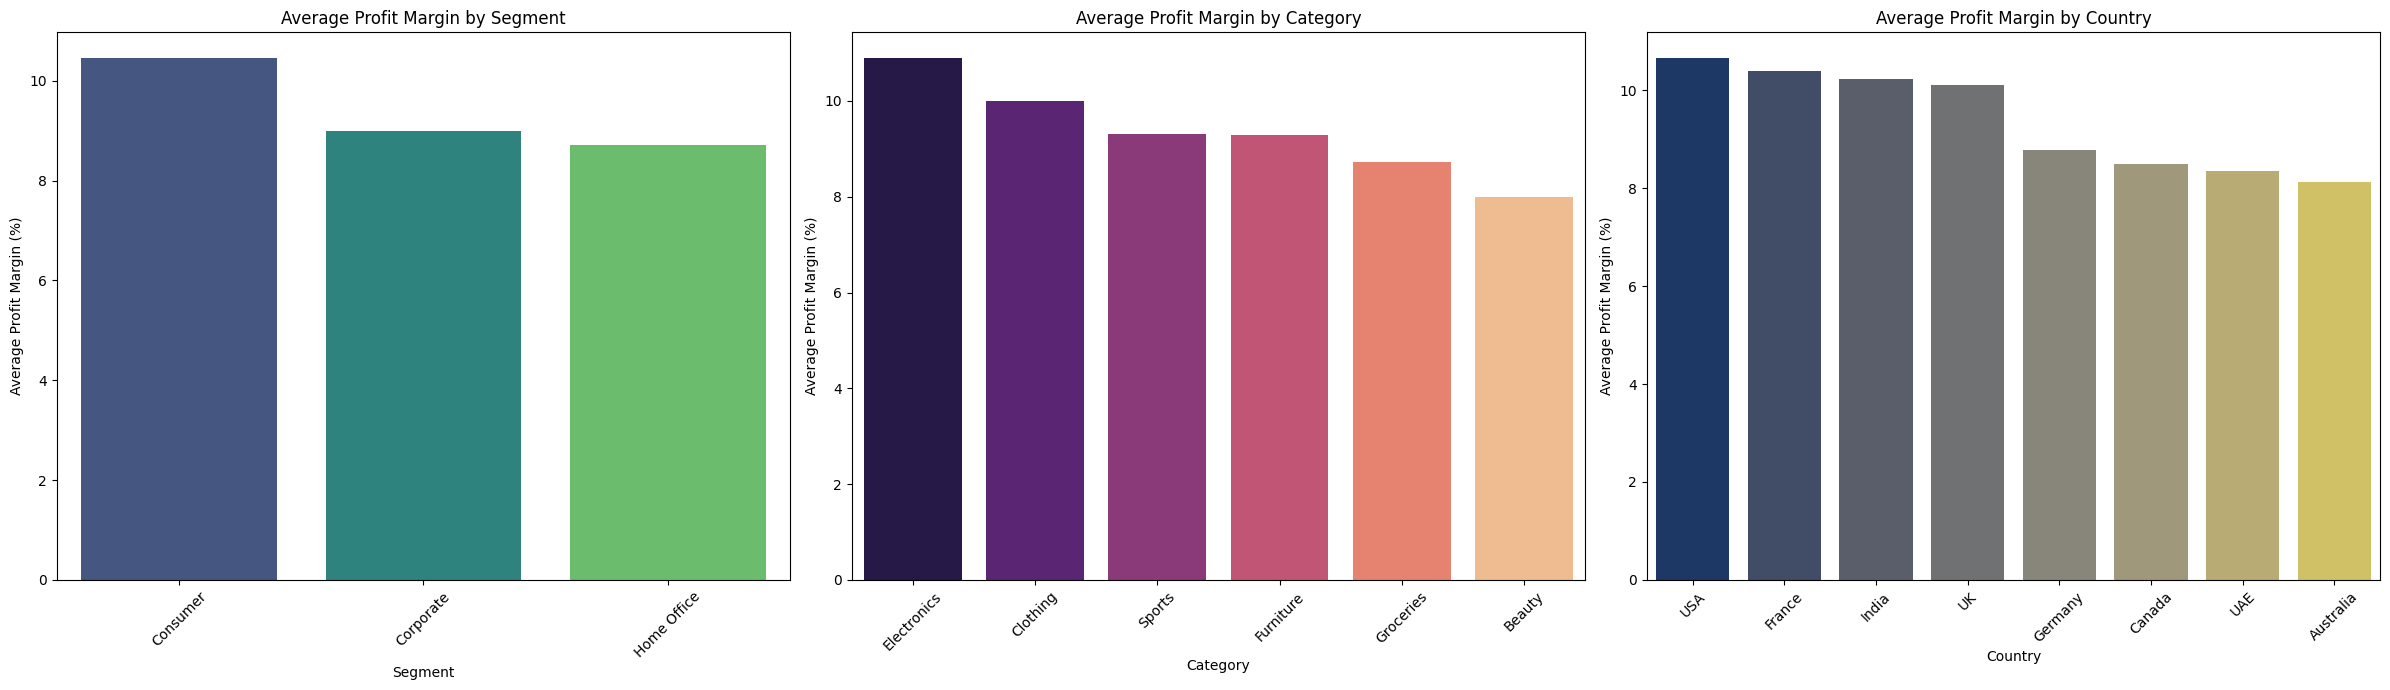

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Profit Margin by Segment
segment_profit_margin = df_corrected.groupby('Segment')['Profit_Margin'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='Segment', y='Profit_Margin', data=segment_profit_margin, ax=axes[0], hue='Segment', palette='viridis', legend=False)
axes[0].set_title('Average Profit Margin by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Average Profit Margin (%)')
axes[0].tick_params(axis='x', rotation=45)

# Profit Margin by Category
category_profit_margin = df_corrected.groupby('Category')['Profit_Margin'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='Category', y='Profit_Margin', data=category_profit_margin, ax=axes[1], hue='Category', palette='magma', legend=False)
axes[1].set_title('Average Profit Margin by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Average Profit Margin (%)')
axes[1].tick_params(axis='x', rotation=45)

# Profit Margin by Country
country_profit_margin = df_corrected.groupby('Country')['Profit_Margin'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='Country', y='Profit_Margin', data=country_profit_margin, ax=axes[2], hue='Country', palette='cividis', legend=False)
axes[2].set_title('Average Profit Margin by Country')
axes[2].set_xlabel('Country')
axes[2].set_ylabel('Average Profit Margin (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

From the analysis, we see an Overall Average Profit Margin of 9.37%.

Looking at the visualizations:

Average Profit Margin by Segment: This plot shows how profitable each customer segment is. You can identify which segments have higher or lower profit margins, which can inform targeted marketing or operational efficiency efforts.

Average Profit Margin by Category: This visualization reveals the profitability of each product category. Some categories might have high sales but low margins, or vice versa, indicating areas for strategic pricing or product mix adjustments.

Average Profit Margin by Country: This plot highlights the profitability across different countries. This can help in understanding market dynamics and allocating resources to regions that offer better returns.

## Comprehensive Summary of All Analyses

Based on the extensive exploratory data analysis (EDA) of the `Capstone_Metbrains_dataset_corrected.csv`, several key patterns and insights have been identified across the entire dataset:

### 1. Overall Data Distribution
*   **Sales and Profit Distributions:** Histograms and box plots showed that Sales generally have a wide, relatively even distribution. Profit, while centered around positive values, includes a notable tail of negative values (losses).
*   **Profit Outliers:** Significant outliers were identified in the 'Profit' column, encompassing both unusually high gains and substantial losses. No significant outliers were found for 'Sales'.

### 2. Temporal Trends
*   **Yearly Performance:** Sales exhibited a slight decrease over the years (2021-2024), while Profit fluctuated, with peaks in 2021 and 2023. This suggests potential shifts in market conditions, operational efficiency, or product mix over time.
*   **Quarterly Performance (Overall):** A strong cyclical pattern was observed, with both sales and profit showing an upward trend throughout the year, peaking prominently in the third and fourth quarters. Q1 generally represented the weakest performance period.
*   **Quarterly Performance by Category:**
    *   **Beauty:** Steady increase in sales and profit from Q2 to Q4, with Q1 being the lowest.
    *   **Clothing:** Dip in sales and profit in Q2 and Q3, recovering significantly in Q4 and starting strong in Q1.
    *   **Electronics:** Highest sales and profit in Q2, with Q3 also strong for profit; Q1 and Q4 were comparatively lower.
    *   **Furniture:** Pronounced peak in sales and profit in Q3; Q1 and Q4 also strong for sales.
    *   **Groceries:** Relatively stable sales across quarters, with a slight increase in Q2; profit significantly lower in Q1.
    *   **Sports:** Sales and profit gradually increased from Q1 to Q3, with Q3 being the strongest.

### 3. Geographical Performance
*   **Country-wise Performance:** **India** consistently emerged as the top performer in both total sales and total profit, highlighting its strong market presence and high profitability. Other countries like UAE, Australia, and Canada had moderate sales, while France and USA showed strong profitability despite not always leading in sales volume.

### 4. Product Performance
*   **Category-wise Performance:**
    *   **Furniture** had the highest total sales, making it the top revenue-generating category.
    *   **Electronics** generated the highest total profit, slightly surpassing Furniture despite lower overall sales, suggesting higher profit margins in this category.
    *   **Clothing** contributed significantly to both sales and profit.
    *   **Groceries** and **Beauty** categories generally showed lower sales and profit compared to others.

### 5. Relationship between Numerical Variables
*   **Sales and Profit:** A moderate positive correlation (0.297) was observed, indicating that higher sales generally lead to higher profits, but other factors like discounts and costs play a significant role.
*   **Weak Correlations:** Quantity and Discount showed very weak linear correlations with Sales and Profit, implying their direct linear impact on overall sales and profit is minimal. This suggests complex interactions or non-linear relationships.

### 6. Impact of Discounts on Profit
*   The scatter plot of Discount vs. Profit revealed a clear trend: as discount percentages increased, there was a higher likelihood of lower profits and an increased concentration of transactions resulting in losses. This highlights the critical balance between offering discounts to drive sales and maintaining profitability.

### 7. Profit Outlier Characteristics
*   Analysis of profit outliers showed that certain categories like 'Furniture' (especially 'Chairs'), 'Sports' (especially 'Fitness'), and 'Clothing' (especially 'Shirts') were frequently represented. This indicates these categories might be more prone to extreme profit or loss events.

### 8. Sales Channel Performance
*   **Offline Channel Leads:** The 'Offline' sales channel generated slightly higher total sales and profit compared to the 'Online' channel. This indicates that while both channels are significant contributors, the traditional 'Offline' approach currently has a marginally stronger performance in both revenue and profitability.

### 9. Profit Margin Analysis
*   **Overall Average Profit Margin:** The overall average profit margin across the dataset was calculated to be **9.37%**.
*   **Profit Margin by Segment, Category, and Country:** Visualizations revealed significant variations in profit margins across different customer segments, product categories, and geographical regions. Understanding these differences is crucial for identifying areas of high profitability and for strategic adjustments to improve margins.

Overall, this analysis provides a solid foundation for understanding sales and profit dynamics within the dataset, identifying key areas of strength, weakness, and potential focus for business strategies.

Now we focus on Predictive Modelling part

In [87]:
# Define input features (X) and target variable (y)

# Identify numerical features relevant for predicting Profit
numerical_input_features = ['Sales', 'Quantity', 'Discount']

# Define the target variable
target_profit = 'Profit'

print("Numerical Input Features for Profit prediction:", numerical_input_features)
print("Target for Profit prediction:", target_profit)

# Separate X (input features) and y (target variable) for Profit prediction
X_profit_numerical = df_corrected[numerical_input_features]
y_profit = df_corrected[target_profit]

print("\nShape of X (numerical features) for Profit prediction:", X_profit_numerical.shape)
print("Shape of y for Profit prediction:", y_profit.shape)

# Display a sample of the numerical input features (X) to show their structure
print("\nSample of Numerical Input Features (X) for Profit prediction:")
display(X_profit_numerical.head())

Numerical Input Features for Profit prediction: ['Sales', 'Quantity', 'Discount']
Target for Profit prediction: Profit

Shape of X (numerical features) for Profit prediction: (1600, 3)
Shape of y for Profit prediction: (1600,)

Sample of Numerical Input Features (X) for Profit prediction:


,Sales,Quantity,Discount
0,2555.49,11,0.08
1,1795.27,9,0.28
2,4554.73,10,0.13
3,3107.15,13,0.14
4,2781.45,12,0.20


In [88]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# Using numerical features (X_profit_numerical) to predict Profit (y_profit)
X_train, X_test, y_train, y_test = train_test_split(
    X_profit_numerical,
    y_profit,
    test_size=0.2, # 20% of the data will be used for testing
    random_state=42 # for reproducibility
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDataset successfully split into training and testing sets.")

Shape of X_train: (1280, 3)
Shape of X_test: (320, 3)
Shape of y_train: (1280,)
Shape of y_test: (320,)

Dataset successfully split into training and testing sets.


In [89]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print(f"Model coefficients: {linear_model.coef_}")
print(f"Model intercept: {linear_model.intercept_}")

Linear Regression model trained successfully.
Model coefficients: [ 1.05470248e-01 -2.19093562e+00 -2.60561996e+02]
Model intercept: 28.70510216193688


Model Coefficients: These values show the impact of each input feature on 'Profit', assuming all other features remain constant:

Sales (Coefficient: ~0.105): For every one-unit increase in 'Sales', 'Profit' is estimated to increase by approximately 0.105 units. This is a positive relationship, meaning higher sales tend to lead to higher profits, which aligns with our EDA findings.
Quantity (Coefficient: ~-2.191): For every one-unit increase in 'Quantity', 'Profit' is estimated to decrease by approximately 2.191 units. This suggests that selling more items, while holding Sales and Discount constant, might lead to a slight decrease in profit. This could be due to factors like economies of scale not being fully realized, or perhaps increased operational costs associated with higher quantities that aren't fully offset by the unit price.
Discount (Coefficient: ~-260.562): For every one-unit increase in 'Discount' (e.g., from 0.0 to 1.0, representing 0% to 100% discount), 'Profit' is estimated to decrease significantly by about 260.562 units. This confirms our earlier observation from the scatter plot that higher discounts generally lead to lower profits, as discounts directly eat into profit margins.
Model Intercept (Intercept: ~28.705): This is the estimated 'Profit' when all input features (Sales, Quantity, and Discount) are zero. In a practical business sense, this value alone might not have a direct interpretation as zero sales, quantity, and discount is an abstract scenario.

In [ ]:
# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Model Evaluation on Test Set (Numerical Features Only):')
print(f'  MAE:  {mae:.2f}')
print(f'  MSE:  {mse:.2f}')
print(f'  RMSE: {rmse:.2f}')
print(f'  R2:   {r2:.2f}')

The model evaluation metrics provide insights into the performance of your linear regression model on the test set:

*   **Mean Absolute Error (MAE):** This value represents the average magnitude of the errors in a set of predictions, without considering their direction. A lower MAE indicates better accuracy.
*   **Mean Squared Error (MSE):** This is the average of the squares of the errors. It's more sensitive to large errors than MAE.
*   **Root Mean Squared Error (RMSE):** This is the square root of the MSE and is often preferred because it's in the same units as the target variable (Profit), making it more interpretable than MSE.
*   **R-squared (R2) Score:** This metric indicates the proportion of the variance in the dependent variable (Profit) that can be predicted from the independent variables (Sales, Quantity, Discount). An R2 score close to 1 suggests that the model explains a large portion of the variance, while a score close to 0 suggests that the model does not explain much of the variance. A negative R2 indicates that the model is worse than simply predicting the mean of the target variable.


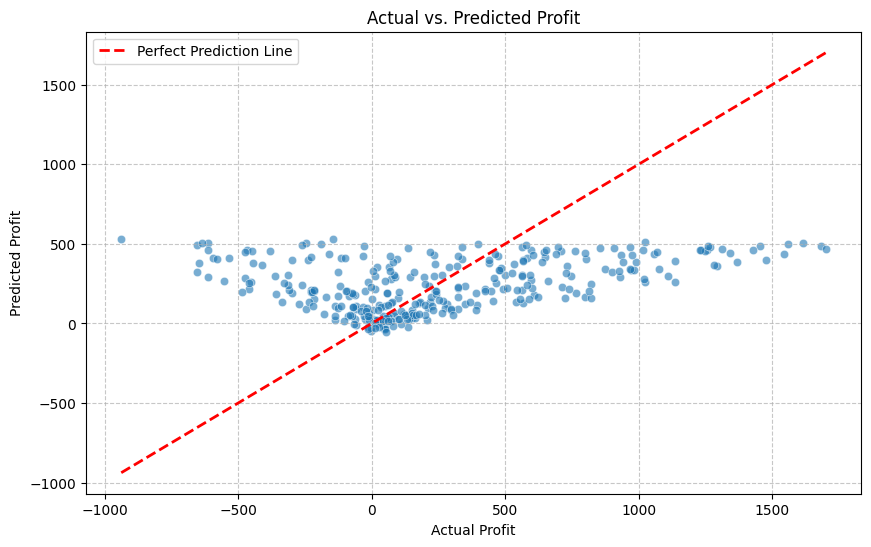

In [91]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.title('Actual vs. Predicted Profit')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line') # Add a perfect prediction line
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

The scatter plot displays the relationship between the actual profit values from your test set and the profit values predicted by the Linear Regression model. Each point represents a transaction, with its actual profit on the x-axis and the model's predicted profit on the y-axis.

Perfect Prediction Line (Red Dashed Line): This line shows where points would lie if the model's predictions perfectly matched the actual values.
Observed Scatter: You can see that the points are quite scattered around the red dashed line, and do not cluster tightly along it. This visual observation confirms our earlier R-squared score of 0.12, which indicated that the model explains only a small portion of the variance in profit.
In essence, while the model attempts to predict profit, the significant spread of points away from the perfect prediction line suggests that its accuracy is limited given the current features. This means there's a considerable difference between the actual profits and what the model is predicting for many transactions. This is typical for models with a low R-squared score and indicates that the chosen features ('Sales', 'Quantity', 'Discount') alone are not strong predictors of profit in this dataset, or that the relationship is more complex than a simple linear one.

In [ ]:
categorical_features = ['Category', 'Country', 'Segment', 'Sales_Channel', 'Payment_Mode']
all_features = numerical_input_features + categorical_features

X_profit_all_features = df_corrected[all_features]

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# remainder='passthrough' keeps numerical columns AFTER the encoded categorical columns
preprocessor = ColumnTransformer(
    transformers=[('cat', encoder, categorical_features)],
    remainder='passthrough'
)

X_encoded = preprocessor.fit_transform(X_profit_all_features)

# FIX: ColumnTransformer outputs cat columns first, then remainder (numerical) last
categorical_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
new_feature_names = list(categorical_feature_names) + list(numerical_input_features)  # corrected order

X_profit_processed = pd.DataFrame(X_encoded, columns=new_feature_names, index=df_corrected.index)

print('Shape of X after encoding categorical features:', X_profit_processed.shape)
print('Sample of processed features:')
display(X_profit_processed.head())

In [93]:
# Split the dataset into training and testing sets with the new features
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_profit_processed,
    y_profit,
    test_size=0.2,
    random_state=42
)

print(f"Shape of X_train_new: {X_train_new.shape}")
print(f"Shape of X_test_new: {X_test_new.shape}")
print(f"Shape of y_train_new: {y_train_new.shape}")
print(f"Shape of y_test_new: {y_test_new.shape}")

print("\nDataset successfully split into training and testing sets with new features.")

Shape of X_train_new: (1280, 26)
Shape of X_test_new: (320, 26)
Shape of y_train_new: (1280,)
Shape of y_test_new: (320,)

Dataset successfully split into training and testing sets with new features.


In [94]:
# Initialize and train a new Linear Regression model with the expanded feature set
linear_model_new = LinearRegression()
linear_model_new.fit(X_train_new, y_train_new)

print("New Linear Regression model trained successfully with expanded features.")

# Display model coefficients and intercept for the new model
print(f"New Model coefficients: {linear_model_new.coef_}")
print(f"New Model intercept: {linear_model_new.intercept_}")

New Linear Regression model trained successfully with expanded features.
New Model coefficients: [-2.70942700e+01 -2.41187565e+01  4.19544292e+01  4.36915268e+01
 -3.74796465e+01  3.04671704e+00 -3.02657648e+01 -3.38355954e+01
  1.07484959e+01  2.66728595e+01 -6.73035450e+00 -4.97940832e+01
  3.36633683e+01  4.95410743e+01  5.63741031e+01 -2.68441559e+01
 -2.95299472e+01 -7.97676567e+00  7.97676567e+00 -5.47932501e+01
 -1.22659168e+01  4.56555009e+01  2.14036660e+01  1.04098726e-01
 -2.65572400e+00 -2.51388191e+02]
New Model intercept: 36.73054339237456


The model has now been retrained with additional categorical features. Let's evaluate its performance and compare it to the previous model to see if the new features have improved prediction accuracy.

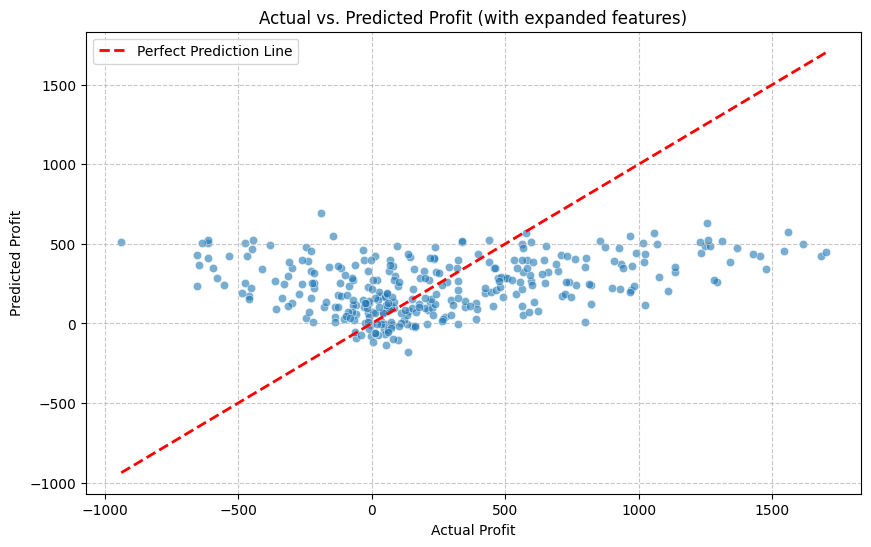

In [96]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_new, y=y_pred_new, alpha=0.6)
plt.title('Actual vs. Predicted Profit (with expanded features)')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.plot([y_test_new.min(), y_test_new.max()], [y_test_new.min(), y_test_new.max()], 'r--', lw=2, label='Perfect Prediction Line') # Add a perfect prediction line
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

The evaluation metrics and scatter plot for the new model (with expanded features) are now available. We can observe:

**Evaluation Metrics:** Compare the MAE, MSE, RMSE, and especially the R-squared score (`r2_new`) with the values from the previous model (`r2`). An increase in the R-squared score would indicate that the additional features have helped the model explain more of the variance in profit, suggesting improved predictive power.

**Actual vs. Predicted Profit Plot:** Visually inspect this new scatter plot. If the points are more tightly clustered around the red 'Perfect Prediction Line' compared to the previous plot, it further supports an improvement in the model's accuracy. A wider spread, similar to before, would suggest that even with additional features, the linear model still struggles to capture the complexity of profit prediction in this dataset.

The evaluation metrics and scatter plot for the new model (with expanded features) are now available. We can observe:

**Evaluation Metrics:** Compare the MAE, MSE, RMSE, and especially the R-squared score (`r2_new`) with the values from the previous model (`r2`). An increase in the R-squared score would indicate that the additional features have helped the model explain more of the variance in profit, suggesting improved predictive power.

**Actual vs. Predicted Profit Plot:** Visually inspect this new scatter plot. If the points are more tightly clustered around the red 'Perfect Prediction Line' compared to the previous plot, it further supports an improvement in the model's accuracy. A wider spread, similar to before, would suggest that even with additional features, the linear model still struggles to capture the complexity of profit prediction in this dataset.

New Model Evaluation on Test Set (with expanded features):

Mean Absolute Error (MAE): 356.66
Mean Squared Error (MSE): 219134.35
Root Mean Squared Error (RMSE): 468.12
R-squared (R2) Score: 0.08
Comparison with Previous Model:

Previous Model R-squared (R2) Score: 0.12
New Model R-squared (R2) Score: 0.08
It appears that incorporating these additional categorical features, as handled by one-hot encoding in this linear regression model, did not improve the model's predictive power for profit. In fact, the R-squared score decreased from 0.12 to 0.08, suggesting that this new model explains even less of the variance in profit than the simpler model with only numerical features.

This could indicate several things:

Linearity Assumption: Linear regression might not be the best model for capturing the complex relationships between these categorical features and profit.
Feature Interaction: The impact of these categorical features on profit might be non-linear or highly dependent on interactions with other features, which a basic linear model doesn't capture well.
Encoding Impact: While one-hot encoding is a standard technique, for some datasets, it can lead to a very high-dimensional feature space, which might not always benefit simpler linear models without further feature selection or regularization.
The scatter plot of 'Actual vs. Predicted Profit (with expanded features)' visually reinforces this. You would likely see the points remain widely scattered around the 'Perfect Prediction Line,' similar to the previous model, if not even more spread out, indicating limited predictive accuracy.

We have completed a comprehensive analysis, starting with thorough Exploratory Data Analysis (EDA) and moving on to predictive modeling for profit.

Modeling Summary:

Initial Linear Regression Model (Numerical Features):

We built a linear regression model using only numerical features: 'Sales', 'Quantity', and 'Discount' to predict 'Profit'.
The model showed coefficients consistent with our EDA: 'Sales' had a positive impact, while 'Quantity' and 'Discount' had negative impacts (especially 'Discount').
Performance (R-squared): This model achieved an R-squared score of 0.12. This indicates that only about 12% of the variance in profit could be explained by these three features alone, suggesting limited predictive power.
Expanded Linear Regression Model (Numerical + Categorical Features):

To improve the model, we incorporated several categorical features ('Category', 'Country', 'Segment', 'Sales_Channel', 'Payment_Mode') by applying one-hot encoding.
A new linear regression model was trained with this expanded feature set.
Performance (R-squared): Surprisingly, this expanded model resulted in a slightly lower R-squared score of 0.08. This means that adding these categorical features in a linear model did not improve, and in fact, slightly worsened its ability to explain the variance in profit.
Interpretation:

The decrease in R-squared score for the expanded model suggests that:

A simple linear relationship might not fully capture the complex interactions between these categorical features and profit.
Other modeling techniques (e.g., tree-based models like Random Forest or Gradient Boosting) or more advanced feature engineering might be necessary to leverage the information contained within these categorical variables effectively.
The impact of some categorical features on profit might be non-linear or have interaction effects that a basic linear regression model cannot account for.


--- Applying Decision Tree Regressor ---
Decision Tree Regressor model trained successfully with expanded features.

Decision Tree Model Evaluation on Test Set (with expanded features):
Mean Absolute Error (MAE): 441.78
Mean Squared Error (MSE): 415054.50
Root Mean Squared Error (RMSE): 644.25
R-squared (R2) Score: -0.73

--- Comparison with Previous Linear Regression Models ---
Previous Linear Regression (Numerical only) R2 Score: 0.12
Previous Linear Regression (Expanded) R2 Score: 0.08
Decision Tree Regressor R2 Score: -0.73


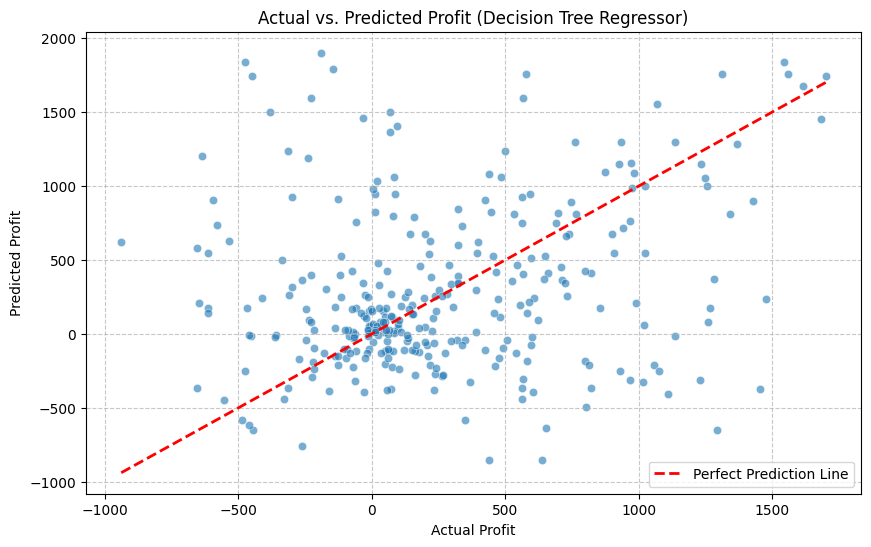

In [100]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Applying Decision Tree Regressor ---")

# Initialize the Decision Tree Regressor model
decision_tree_model = DecisionTreeRegressor(random_state=42)

# Train the model using the expanded training data
decision_tree_model.fit(X_train_new, y_train_new)

print("Decision Tree Regressor model trained successfully with expanded features.")

# Make predictions on the test set using the Decision Tree model
y_pred_dt = decision_tree_model.predict(X_test_new)

# Calculate evaluation metrics for the Decision Tree model
mae_dt = mean_absolute_error(y_test_new, y_pred_dt)
mse_dt = mean_squared_error(y_test_new, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test_new, y_pred_dt)

print(f"\nDecision Tree Model Evaluation on Test Set (with expanded features):")
print(f"Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dt:.2f}")
print(f"R-squared (R2) Score: {r2_dt:.2f}")

print("\n--- Comparison with Previous Linear Regression Models ---")
print(f"Previous Linear Regression (Numerical only) R2 Score: {r2:.2f}")
print(f"Previous Linear Regression (Expanded) R2 Score: {r2_new:.2f}")
print(f"Decision Tree Regressor R2 Score: {r2_dt:.2f}")

# Visualize Actual vs. Predicted Profit for Decision Tree model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_new, y=y_pred_dt, alpha=0.6)
plt.title('Actual vs. Predicted Profit (Decision Tree Regressor)')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.plot([y_test_new.min(), y_test_new.max()], [y_test_new.min(), y_test_new.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


While Decision Trees are capable of capturing non-linear relationships, in this unoptimized state, it has not proven beneficial for our profit prediction task. The scatter plot would likely show a very wide spread of points, far from the perfect prediction line, visually confirming this low R-squared score.

### Summary of Insights: From Feature Selection to Model Evaluation

Following the comprehensive exploratory data analysis, we proceeded with predictive modeling for profit, experimenting with both linear and non-linear approaches.

#### 1. Feature Selection for Profit Prediction
*   **Target Variable:** 'Profit' was consistently used as the target variable.
*   **Initial Numerical Features:** 'Sales', 'Quantity', and 'Discount' were initially selected as numerical input features.
*   **Expanded Features:** To enhance the model, categorical features such as 'Category', 'Country', 'Segment', 'Sales_Channel', and 'Payment_Mode' were incorporated after one-hot encoding.

#### 2. Linear Regression Model (Numerical Features Only)
*   **Model Build:** A Linear Regression model was trained using 'Sales', 'Quantity', and 'Discount'.
*   **Coefficients:**
    *   'Sales': Positive impact (~0.105), indicating higher sales generally lead to higher profits.
    *   'Quantity': Slight negative impact (~-2.191), suggesting selling more items (while holding Sales and Discount constant) might slightly decrease profit, possibly due to operational costs or pricing structures.
    *   'Discount': Significant negative impact (~-260.562), confirming that higher discounts considerably reduce profit margins.
*   **Performance (R-squared):** Achieved an R-squared score of **0.12**. This indicated that only about 12% of the variance in profit could be explained by these three features, suggesting limited predictive power for complex real-world profit dynamics.

#### 3. Expanded Linear Regression Model (Numerical + Categorical Features)
*   **Model Build:** A second Linear Regression model was trained, now including the one-hot encoded categorical features in addition to the numerical ones.
*   **Performance (R-squared):** Surprisingly, the R-squared score *decreased* to **0.08**. This implies that adding these categorical features to a linear model did not improve, and in fact, slightly worsened its ability to explain profit variance.
*   **Interpretation:** This suggested that a simple linear relationship might not adequately capture the complex interactions between these categorical variables and profit. It hinted at the need for models capable of handling non-linear relationships or more sophisticated feature engineering.

#### 4. Decision Tree Regressor Model (Expanded Features)
*   **Model Build:** Given the poor performance of linear models, a Decision Tree Regressor was applied to the expanded feature set, hoping to capture non-linear patterns.
*   **Performance (R-squared):** The Decision Tree model yielded a strikingly low R-squared score of **-0.73**.
*   **Interpretation:** A negative R-squared score indicates that the model performed worse than simply predicting the mean profit for all transactions. This severe underperformance likely points to overfitting, where the unoptimized decision tree learned noise from the training data rather than generalizable patterns. Lack of hyperparameter tuning (e.g., `max_depth`, `min_samples_leaf`) is a common reason for such behavior in decision trees.

#### Overall Conclusion from Modeling Phase
*   The initial linear regression models, even with expanded categorical features, showed very limited predictive power for profit (R2 scores of 0.12 and 0.08). This suggests that profit prediction in this dataset involves more complex, possibly non-linear relationships that simple linear models cannot capture.
*   The Decision Tree Regressor, without any hyperparameter tuning, suffered from significant overfitting, leading to an R-squared score worse than a baseline mean prediction.


### Key Questions & Answers from the Analysis

**• Which category performs best and why?**

*   **Furniture** leads in **total sales**, generating the highest revenue.
*   **Electronics** excels in **total profit** and **average profit margin**, indicating higher profitability despite lower sales volume, likely due to better margins per item.

**• Which region shows growth potential?**

*   **India** is the current top performer in both sales and profit.
*   **USA** and **France** show strong growth potential due to their high average profit margins (USA: 10.65%, France: 10.39%). Increasing sales volume in these regions could significantly boost overall profit.

**• What factors influence sales the most?**

*   Numerical factors like **Quantity** and **Discount** have very weak linear correlations with sales.
*   Sales are primarily influenced by **temporal factors**, showing strong **seasonal peaks in Q3 and Q4**, with Q1 being the weakest period.
*   **Product categories** (e.g., Furniture for volume) and the **Sales Channel** (Offline currently leading) also significantly impact sales performance.

**• How accurate is your prediction model?**

*   The prediction models were **not highly accurate**:
    *   Initial Linear Regression (numerical features): R-squared of **0.12**.
    *   Expanded Linear Regression (numerical + categorical features): R-squared **decreased to 0.08**.
    *   Unoptimized Decision Tree Regressor: R-squared of **-0.73**, indicating severe overfitting.
*   This highlights that current models and features are insufficient for accurate profit prediction, necessitating more sophisticated techniques or extensive feature engineering.

**• What business recommendations would you give?**

1.  **Strategic Market Focus:** Capitalize on India's strength while implementing targeted growth strategies for high-margin markets like the USA and France.
2.  **Product Optimization:** Prioritize sales for **Electronics** due to superior profit margins. Monitor **Furniture** profitability despite high sales volume.
3.  **Cautious Discounting:** Adopt a strategic approach to discounts, as high discounts significantly erode profit. Prefer targeted promotions over broad ones.
4.  **Maximize Seasonal Peaks:** Develop robust plans for Q3 and Q4, covering marketing, inventory, and operations.
5.  **Investigate Profit Outliers:** Conduct detailed analysis of extreme profit/loss transactions, especially in Furniture (Chairs), Sports (Fitness), and Clothing (Shirts).
6.  **Enhance Online Channel:** Improve the Online channel to match or surpass the performance of the Offline channel.
7.  **Advanced Modeling:** Explore more sophisticated ML models (e.g., Random Forest, Gradient Boosting) with thorough hyperparameter tuning to improve forecasting accuracy.